In [2]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import seaborn as sns 
import matplotlib.pyplot as plt



PATH_TO_PLOTS = 'data/plots'
if not os.path.exists(PATH_TO_PLOTS):
    os.makedirs(PATH_TO_PLOTS)

In [3]:
strain_names = ["Ab17978", "Kp43816", "PAO1", "AbLac4", "Kp0087", "Pa0095"]
dict_paths = {}

for strain in strain_names:
    dict_paths[strain] = {"model":f"../data/final_models/{strain}_final_model.pkl",
                          "predictions":f"../data/final_models/{strain}_predictions.csv"}


In [4]:
def plot_percentage_confusion_matrix(cm, ax, class_names=None):
    """
    Plots a confusion matrix heatmap colored by row percentages directly onto
    a provided matplotlib Axis object.
    """
    # 1. Calculate percentages (normalize by true labels/rows)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_perc = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums!=0)
    
    # 2. Build custom annotation labels combining count and percentage
    blanks = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            cnt = cm[i, j]
            pct = cm_perc[i, j] * 100
            blanks[i, j] = f"{cnt}\n({pct:.1f}%)"
            
    # 3. Plot onto the passed axis (ax=ax)
    sns.heatmap(
        cm_perc, 
        annot=blanks, 
        fmt="",            
        cmap="Blues", 
        vmin=0, vmax=1,    
        xticklabels=class_names if class_names else True,
        yticklabels=class_names if class_names else True,
        ax=ax,             # <--- This directs seaborn to the specific subplot
        cbar=True          # Set to False if you don't want a colorbar for every subplot
    )
    
    # Use ax.set_* methods instead of plt.set_* for subplots
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    
    return ax

Ab17978
Precision:0.28
Recall:0.48
Kp43816
Precision:0.21
Recall:0.30
PAO1
Precision:0.19
Recall:0.34
AbLac4
Precision:0.27
Recall:0.48
Kp0087
Precision:0.30
Recall:0.56
Pa0095
Precision:0.27
Recall:0.55


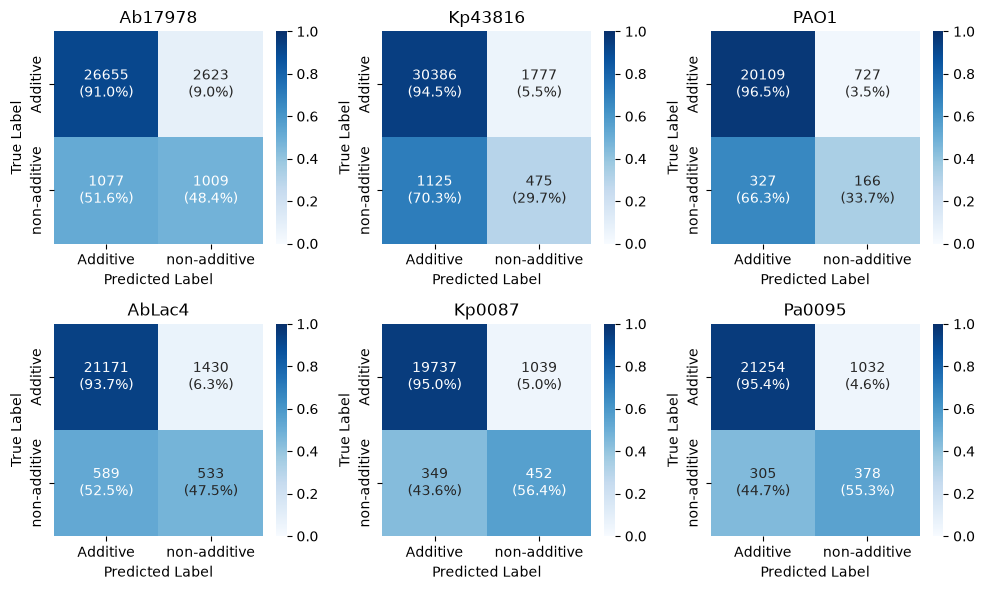

In [5]:
fig, axes = plt.subplots(2,3, figsize=(10, 6))

axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easier iteration
for i, strain in enumerate(strain_names):


    model = joblib.load(dict_paths[strain]["model"])
    predictions_df = pd.read_csv(dict_paths[strain]["predictions"])
    threshold = 0.8  # Set your desired threshold here

    y_test = predictions_df["true_labels"].values
    y_predict_proba = predictions_df["predictions_prob"].values

    y_pred = (y_predict_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print(f"{strain}\nPrecision:{precision:.2f}\nRecall:{recall:.2f}")

    cm = confusion_matrix(y_test, y_pred)
    

    plot_percentage_confusion_matrix(cm, axes[i], class_names=["Additive", "non-additive"])
    axes[i].set_title(f"{strain}")

plt.tight_layout()


    